In [3]:
pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.6 MB/s eta 0:00:00


In [14]:
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import resample, firwin, lfilter
from scipy.signal import correlate, iirnotch, butter, filtfilt

In [ ]:
#Problema 1

fs = 500
t = np.arange(0,2, 1/fs)

signal1 = np.sin(2*np.pi*5*t)
signal2 = np.sin(2*np.pi*20*t)
signal3 = np.sin(2*np.pi*80*t)

signal = signal1 + signal2 + signal3

In [ ]:
fir = firwin(
    101,
    [15,30],
    pass_zero=False,
    fs=fs
)
filtered = lfilter(fir, 1.0, signal)

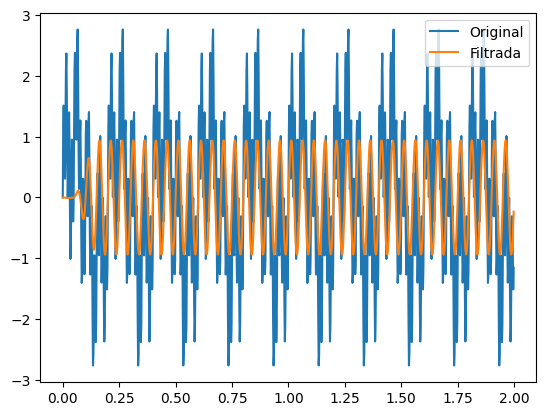

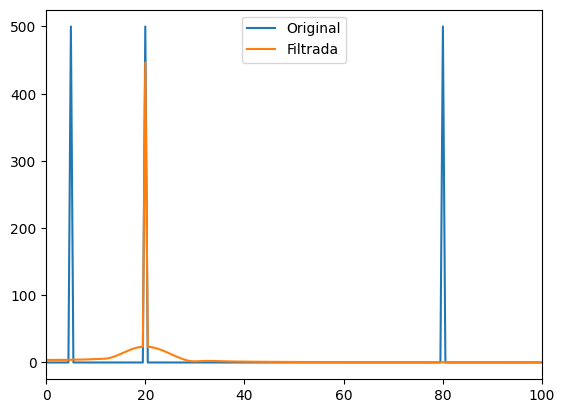

In [ ]:
#FFT

fft_original = np.abs(np.fft.fft(signal))
fft_filtered = np.abs(np.fft.fft(filtered))
freq = np.fft.fftfreq(len(signal), 1/fs)

#Señal temporal

plt.plot(t, signal, label='Original')
plt.plot(t, filtered, label='Filtrada')
plt.legend()
plt.show()

plt.plot(freq[:len(freq)//2], fft_original[:len(freq)//2], label='Original')
plt.plot(freq[:len(freq)//2], fft_filtered[:len(freq)//2], label='Filtrada')

plt.xlim(0, 100)
plt.legend()
plt.show()

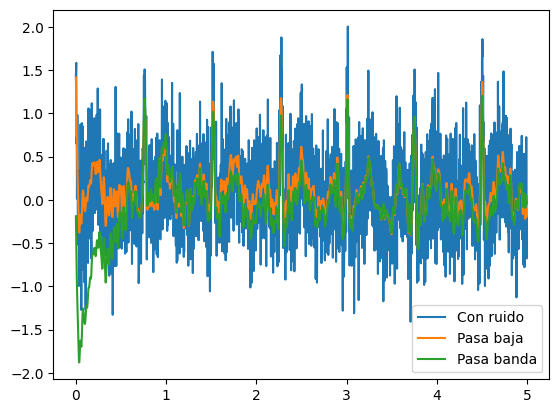

In [ ]:
#Problema 2

fs = 500
t = np.arange(0, 5, 1/fs)

ecg = nk.ecg_simulate(duration=5, sampling_rate=fs, heart_rate=80)

ruido_blanco = 0.3*np.random.randn(len(ecg))

interferencia = 0.4*np.sin(2*np.pi*80*t)

noisy = ecg + ruido_blanco + interferencia

b, a = butter(4, 40, btype='low', fs=fs)
lowpass = filtfilt(b, a, noisy)

b, a = butter(4, [0.5, 40], btype='bandpass', fs=fs)
bandpass = filtfilt(b, a, noisy)

plt.plot(t, noisy, label='Con ruido')
plt.plot(t, lowpass, label='Pasa baja')
plt.plot(t, bandpass, label='Pasa banda')
plt.legend()
plt.show()


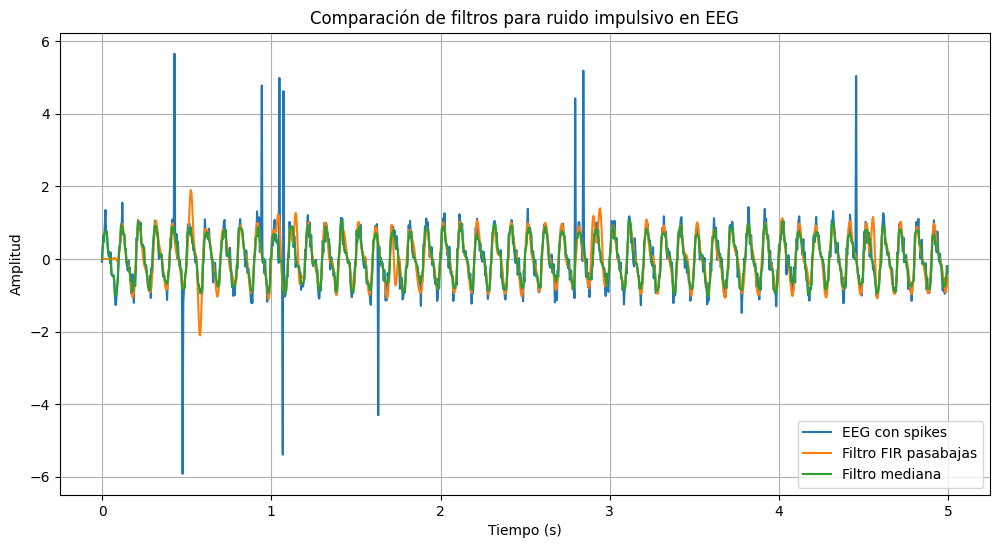

In [7]:
#Problema 3

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, medfilt

fs = 250
t = np.arange(0, 5, 1/fs)

eeg = 0.8*np.sin(2*np.pi*10*t) + 0.3*np.sin(2*np.pi*20*t) + 0.2*np.random.randn(len(t))

np.random.seed(1)
pos_spikes = np.random.choice(len(eeg), 10, replace=False)

eeg_con_spikes = eeg.copy()
eeg_con_spikes[pos_spikes] += np.random.choice([5, -5], size=10)

fir = firwin(51, 30, fs=fs)
eeg_fir = lfilter(fir, 1.0, eeg_con_spikes)

eeg_mediana = medfilt(eeg_con_spikes, kernel_size=5)

plt.figure(figsize=(12, 6))

plt.plot(t, eeg_con_spikes, label="EEG con spikes")
plt.plot(t, eeg_fir, label="Filtro FIR pasabajas")
plt.plot(t, eeg_mediana, label="Filtro mediana")

plt.title("Comparación de filtros para ruido impulsivo en EEG")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

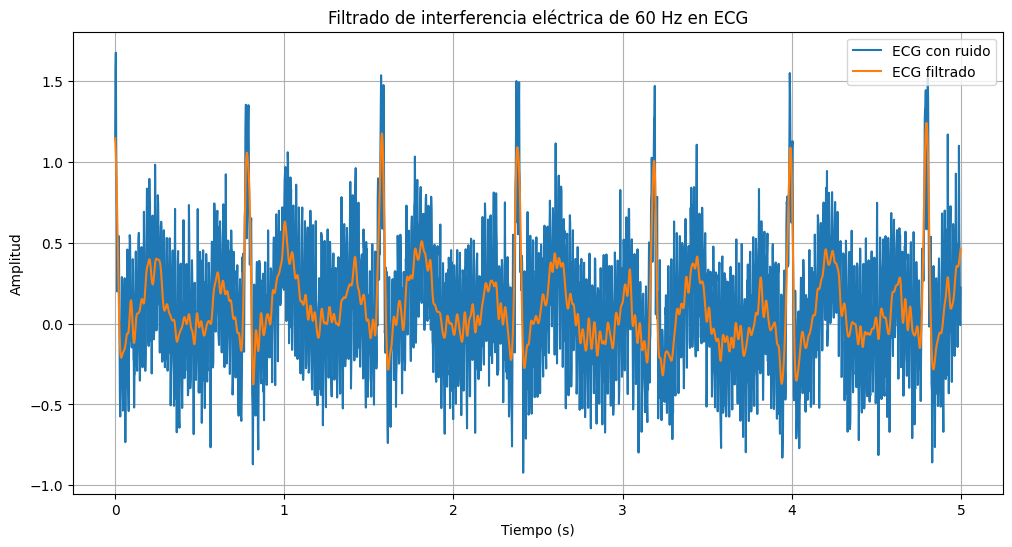

In [11]:
#Problema 4

fs = 500
t = np.arange(0, 5, 1/fs)

ecg = nk.ecg_simulate(duration=5, sampling_rate=fs, heart_rate=75)

ruido_60hz = 0.4*np.sin(2*np.pi*60*t)

ruido_blanco = 0.15*np.random.randn(len(t))

ecg_ruidoso = ecg + ruido_60hz + ruido_blanco

b_notch, a_notch = iirnotch(60, 30, fs)
ecg_sin_60hz = filtfilt(b_notch, a_notch, ecg_ruidoso)

b_low, a_low = butter(4, 40, btype="low", fs=fs)
ecg_filtrado = filtfilt(b_low, a_low, ecg_sin_60hz)

plt.figure(figsize=(12, 6))

plt.plot(t, ecg_ruidoso, label="ECG con ruido")
plt.plot(t, ecg_filtrado, label="ECG filtrado")

plt.title("Filtrado de interferencia eléctrica de 60 Hz en ECG")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

Delay estimado respiración: -1.936 segundos
Delay estimado acelerómetro: 3.712 segundos


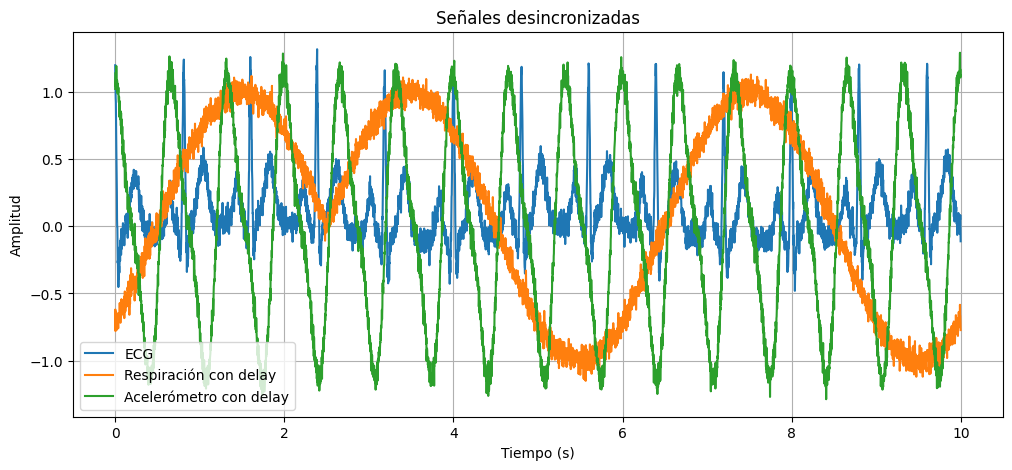

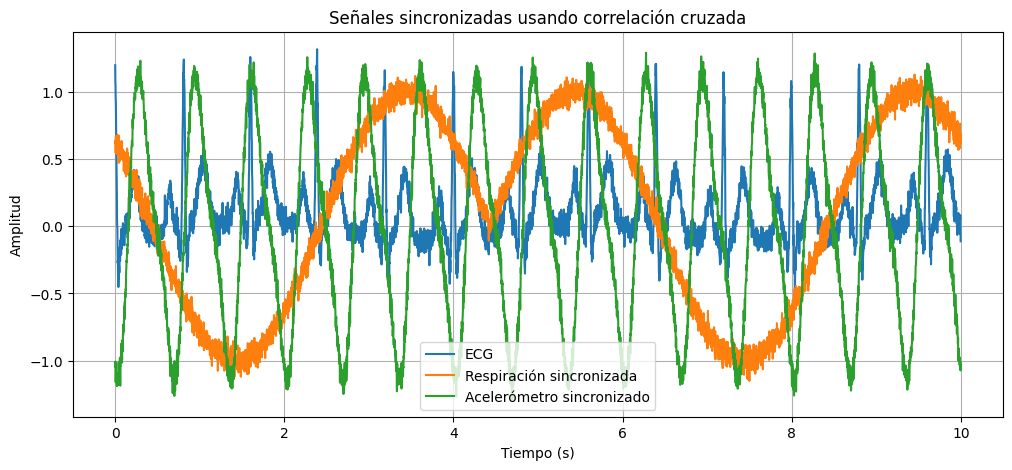

In [13]:
#Problema 5

fs = 500
duracion = 10
t = np.arange(0, duracion, 1/fs)

ecg = nk.ecg_simulate(duration=duracion, sampling_rate=fs, heart_rate=75)
resp = np.sin(2*np.pi*0.25*t)
acc = np.sin(2*np.pi*1.5*t) + 0.3*np.sin(2*np.pi*3*t)

delay_resp = int(2.5 * fs)
delay_acc = int(3.2 * fs)

resp_delay = np.roll(resp, delay_resp) + 0.05*np.random.randn(len(resp))
acc_delay = np.roll(acc, delay_acc) + 0.05*np.random.randn(len(acc))
ecg_ruido = ecg + 0.05*np.random.randn(len(ecg))

def estimar_delay(s1, s2):
    corr = correlate(s2, s1, mode="full")
    delay = np.argmax(corr) - len(s1) + 1
    return delay

delay_estimado_resp = estimar_delay(ecg_ruido, resp_delay)
delay_estimado_acc = estimar_delay(ecg_ruido, acc_delay)

resp_sync = np.roll(resp_delay, -delay_estimado_resp)
acc_sync = np.roll(acc_delay, -delay_estimado_acc)

print("Delay estimado respiración:", delay_estimado_resp/fs, "segundos")
print("Delay estimado acelerómetro:", delay_estimado_acc/fs, "segundos")

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_ruido, label="ECG")
plt.plot(t, resp_delay, label="Respiración con delay")
plt.plot(t, acc_delay, label="Acelerómetro con delay")
plt.title("Señales desincronizadas")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_ruido, label="ECG")
plt.plot(t, resp_sync, label="Respiración sincronizada")
plt.plot(t, acc_sync, label="Acelerómetro sincronizado")
plt.title("Señales sincronizadas usando correlación cruzada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

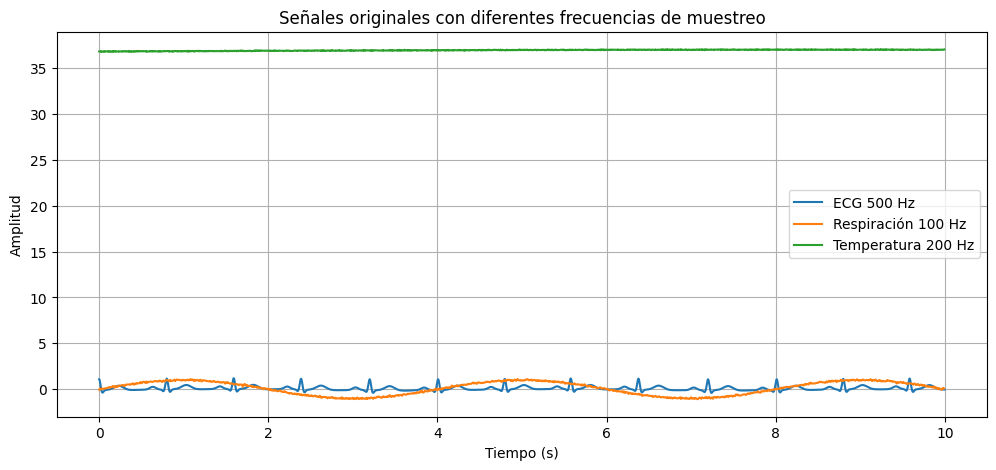

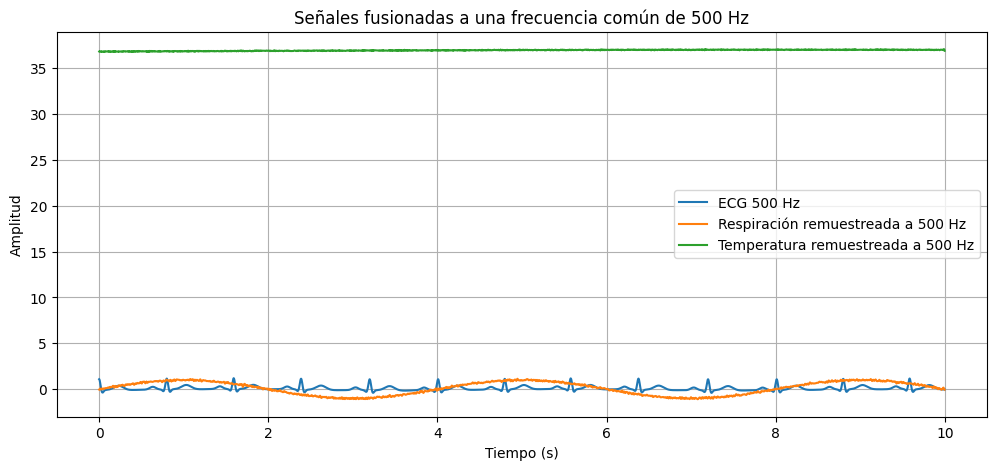

In [15]:
#Problema 6

duracion = 10

fs_ecg = 500
fs_resp = 100
fs_temp = 200

t_ecg = np.arange(0, duracion, 1/fs_ecg)
t_resp = np.arange(0, duracion, 1/fs_resp)
t_temp = np.arange(0, duracion, 1/fs_temp)

ecg = nk.ecg_simulate(duration=duracion, sampling_rate=fs_ecg, heart_rate=75)

resp = np.sin(2*np.pi*0.25*t_resp) + 0.05*np.random.randn(len(t_resp))

temp = 36.8 + 0.2*np.sin(2*np.pi*0.03*t_temp) + 0.02*np.random.randn(len(t_temp))

resp_500 = resample(resp, len(ecg))
temp_500 = resample(temp, len(ecg))

t = t_ecg

plt.figure(figsize=(12, 5))
plt.plot(t_ecg, ecg, label="ECG 500 Hz")
plt.plot(t_resp, resp, label="Respiración 100 Hz")
plt.plot(t_temp, temp, label="Temperatura 200 Hz")
plt.title("Señales originales con diferentes frecuencias de muestreo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, ecg, label="ECG 500 Hz")
plt.plot(t, resp_500, label="Respiración remuestreada a 500 Hz")
plt.plot(t, temp_500, label="Temperatura remuestreada a 500 Hz")
plt.title("Señales fusionadas a una frecuencia común de 500 Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()